<a href="https://colab.research.google.com/github/minseonju/Marine/blob/main/model/lstm/LSTM_ae_exfiltration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# [셀 1] Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# [셀 2] 라이브러리 import & 전역 설정
import os
import pickle
import random

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

config = {
    'batch_size'  : 256,
    'epochs'      : 300,
    'hidden_dim'  : 64,
    'lr'          : 0.0001,
    'weight_decay': 1e-5,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")


사용 디바이스: cuda


In [ ]:
# [셀 3] 데이터 로드 & 시퀀스 생성
import pandas as pd
import numpy as np

# 학습: raw_events.csv
df_train = pd.read_csv('/content/drive/MyDrive/raw_events.csv')
df_train = df_train.sort_values('ts_ns').reset_index(drop=True)

# 테스트: raw_data_exfiltration.csv (label 컬럼 없음)
df_test = pd.read_csv('/content/drive/MyDrive/raw_data_exfiltration.csv')
df_test = df_test.sort_values('ts_ns').reset_index(drop=True)

# 학습/테스트 syscall 합집합 기준으로 사전 생성
unique_syscalls = sorted(set(df_train['syscall'].unique()) | set(df_test['syscall'].unique()))
syscall_to_idx  = {s: i for i, s in enumerate(unique_syscalls)}
VOCAB_SIZE      = len(unique_syscalls)
print(f"고유 syscall 수: {VOCAB_SIZE}개")

WINDOW_NS  = int(1e9)
SEQ_WINDOW = 3

# 학습 벡터 생성
ts_min = df_train['ts_ns'].min()
df_train['window_id'] = ((df_train['ts_ns'] - ts_min) // WINDOW_NS).astype(int)

grouped = df_train.groupby('window_id')['syscall'].value_counts().unstack(fill_value=0)
grouped = grouped.reindex(columns=unique_syscalls, fill_value=0)

train_vectors = grouped.values.astype(np.float32)
train_vectors = train_vectors / (train_vectors.sum(axis=1, keepdims=True) + 1e-8)

train_seqs = []
for i in range(0, len(train_vectors) - SEQ_WINDOW + 1):
    train_seqs.append(train_vectors[i:i + SEQ_WINDOW])

random.seed(SEED)
train_seqs = random.sample(train_seqs, min(200_000, len(train_seqs)))
train_seqs = np.array(train_seqs)
print(f"학습 시퀀스: {len(train_seqs):,}개  shape: {train_seqs.shape}")

# 테스트 벡터 생성 (label 없음 - 전체 시퀀스)
ts_min_test = df_test['ts_ns'].min()
df_test['window_id'] = ((df_test['ts_ns'] - ts_min_test) // WINDOW_NS).astype(int)

grouped_test = df_test.groupby('window_id')['syscall'].value_counts().unstack(fill_value=0)
grouped_test = grouped_test.reindex(columns=unique_syscalls, fill_value=0)
test_vectors = grouped_test.values.astype(np.float32)
test_vectors = test_vectors / (test_vectors.sum(axis=1, keepdims=True) + 1e-8)

test_seqs = []
for i in range(0, len(test_vectors) - SEQ_WINDOW + 1):
    test_seqs.append(test_vectors[i:i + SEQ_WINDOW])

test_seqs = np.array(test_seqs)
print(f"테스트 시퀀스: {len(test_seqs):,}개  shape: {test_seqs.shape}")


고유 syscall 수: 102개
학습 시퀀스: 45,087개  shape: (45087, 3, 102)
테스트 시퀀스: 20개  shape: (20, 3, 102)


In [ ]:
# [셀 4] numpy 배열을 PyTorch 텐서로 변환
X_train = torch.tensor(train_seqs, dtype=torch.float32).to(device)
X_test  = torch.tensor(test_seqs,  dtype=torch.float32).to(device)

print(f"학습: {X_train.shape}  테스트: {X_test.shape}")


학습: torch.Size([45087, 3, 102])  테스트: torch.Size([20, 3, 102])


In [ ]:
# [셀 5] LSTM-AE 모델 정의 & 학습
from torch.utils.data import DataLoader, TensorDataset

class LSTM_AE(nn.Module):
    def __init__(
        self,
        seq_len   : int = SEQ_WINDOW,
        input_dim : int = VOCAB_SIZE,
        hidden_dim: int = config['hidden_dim'],
    ) -> None:
        super().__init__()
        self.seq_len  = seq_len
        self.encoder  = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=3, batch_first=True, dropout=0.2,
        )
        self.decoder  = nn.LSTM(
            hidden_dim, input_dim,
            num_layers=3, batch_first=True, dropout=0.2,
        )
        self.dropout  = nn.Dropout(0.2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        enc_out, (h, c) = self.encoder(x)
        dec_input       = torch.flip(enc_out, dims=[1])
        dec_out, _      = self.decoder(dec_input)
        dec_out         = self.dropout(dec_out)
        return dec_out

model     = LSTM_AE().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

loader = DataLoader(TensorDataset(X_train), batch_size=config['batch_size'], shuffle=True)

train_losses: list[float] = []
best_loss    = float('inf')
patience_cnt = 0
PATIENCE     = 20
os.makedirs('model', exist_ok=True)

print("학습 시작...")
for epoch in range(config['epochs']):
    model.train()
    total_loss = 0.0
    for (batch,) in loader:
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss    = avg_loss
        patience_cnt = 0
        torch.save(model.state_dict(), 'model/best_lstm_ae.pth')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early Stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f} | Patience: {patience_cnt}/{PATIENCE}")

print(f"학습 완료! Best Loss: {best_loss:.6f}")


학습 시작...
Epoch   0 | Loss: 0.002318 | LR: 0.000100 | Patience: 0/20
Epoch  10 | Loss: 0.001360 | LR: 0.000100 | Patience: 0/20
Epoch  20 | Loss: 0.001348 | LR: 0.000100 | Patience: 2/20
Epoch  30 | Loss: 0.001348 | LR: 0.000100 | Patience: 4/20
Epoch  40 | Loss: 0.001346 | LR: 0.000050 | Patience: 7/20
Epoch  50 | Loss: 0.001341 | LR: 0.000050 | Patience: 0/20
Epoch  60 | Loss: 0.001342 | LR: 0.000050 | Patience: 3/20
Epoch  70 | Loss: 0.001342 | LR: 0.000050 | Patience: 1/20
Epoch  80 | Loss: 0.001339 | LR: 0.000050 | Patience: 7/20
Epoch  90 | Loss: 0.001346 | LR: 0.000025 | Patience: 17/20
Early Stopping at epoch 93
학습 완료! Best Loss: 0.001337


In [ ]:
# [셀 6] 복원 오차 계산 (label 없음 - 전체 시퀀스)
def compute_reconstruction_errors(model, X, batch_sz):
    model.eval()
    errors = []
    with torch.no_grad():
        for i in range(0, len(X), batch_sz):
            batch  = X[i:i + batch_sz]
            output = model(batch)
            err    = torch.mean((output - batch) ** 2, dim=(1, 2))
            errors.extend(err.cpu().numpy())
    return np.array(errors)

BATCH_SIZE  = config['batch_size']
test_errors = compute_reconstruction_errors(model, X_test, BATCH_SIZE)

print(f"테스트 오차 — mean: {test_errors.mean():.6f}, std: {test_errors.std():.6f}")

pct_range = np.arange(50, 99, 0.5)

best_t = np.percentile(test_errors, 95)
threshold = best_t

print(f"\n=== Percentile 임계값 ===")
print(f"임계값: {threshold:.6f}")

y_pred = (test_errors > threshold).astype(int)
n_anomaly = y_pred.sum()
n_total   = len(y_pred)
print(f"\n탐지 결과: {n_total}개 시퀀스 중 {n_anomaly}개 이상 탐지 ({n_anomaly/n_total*100:.1f}%)")

anomaly_indices = np.where(y_pred == 1)[0]
print(f"이상 탐지 구간 인덱스: {anomaly_indices.tolist()}")

테스트 오차 — mean: 0.001226, std: 0.000144

=== Percentile 임계값 ===
임계값: 0.001451

탐지 결과: 20개 시퀀스 중 1개 이상 탐지 (5.0%)
이상 탐지 구간 인덱스: [11]


Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


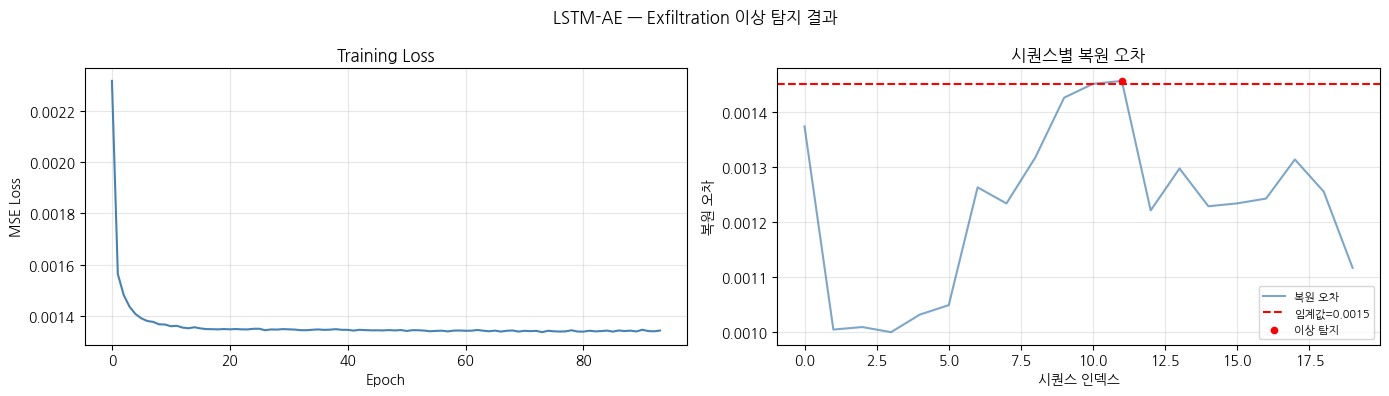

총 시퀀스: 20개
이상 탐지: 1개 (5.0%)
임계값: 0.001451


In [ ]:
# [셀 7] 결과 시각화 (label 없음 버전)
from scipy.stats import gaussian_kde

!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family']        = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('LSTM-AE — Exfiltration 이상 탐지 결과')

# Training Loss
axes[0].plot(train_losses, color='steelblue')
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='MSE Loss')
axes[0].grid(True, alpha=0.3)

# 복원 오차 분포 (시간 순)
axes[1].plot(range(len(test_errors)), test_errors, color='steelblue', alpha=0.7, label='복원 오차')
axes[1].axhline(threshold, color='red', linestyle='--', label=f'임계값={threshold:.4f}')
axes[1].scatter(anomaly_indices, test_errors[anomaly_indices], color='red', s=20, zorder=5, label='이상 탐지')
axes[1].set(title='시퀀스별 복원 오차', xlabel='시퀀스 인덱스', ylabel='복원 오차')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_exfiltration_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"총 시퀀스: {len(test_errors)}개")
print(f"이상 탐지: {n_anomaly}개 ({n_anomaly/n_total*100:.1f}%)")
print(f"임계값: {threshold:.6f}")


In [ ]:
# [셀 8] 모델 저장
os.makedirs('model', exist_ok=True)

with open('model/syscall_to_idx.pkl', 'wb') as f:
    pickle.dump(syscall_to_idx, f)
np.save('model/threshold.npy', threshold)
np.save('model/test_errors.npy', test_errors)

print("로컬 저장 완료")

DRIVE_OUT = '/content/drive/MyDrive'
np.save(f'{DRIVE_OUT}/lstm_exfiltration_errors.npy', test_errors)
np.save(f'{DRIVE_OUT}/lstm_exfiltration_threshold.npy', threshold)
torch.save(model.state_dict(), f'{DRIVE_OUT}/best_lstm_ae_exfiltration.pth')

print("Drive 저장 완료")


In [ ]:
# [셀 9] 모델 파일 다운로드
from google.colab import files

files.download('model/best_lstm_ae.pth')
files.download('model/syscall_to_idx.pkl')
files.download('model/threshold.npy')

print("다운로드 완료!")
